# Modèle linéaire (Perceptron)

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [12]:
# Extraction des données

path_dataset = "../datasets/toy"

linear = pd.read_csv(path_dataset + "/linear.csv")
xor = pd.read_csv(path_dataset + "/xor.csv")

## Visualisation des données avant entraînement

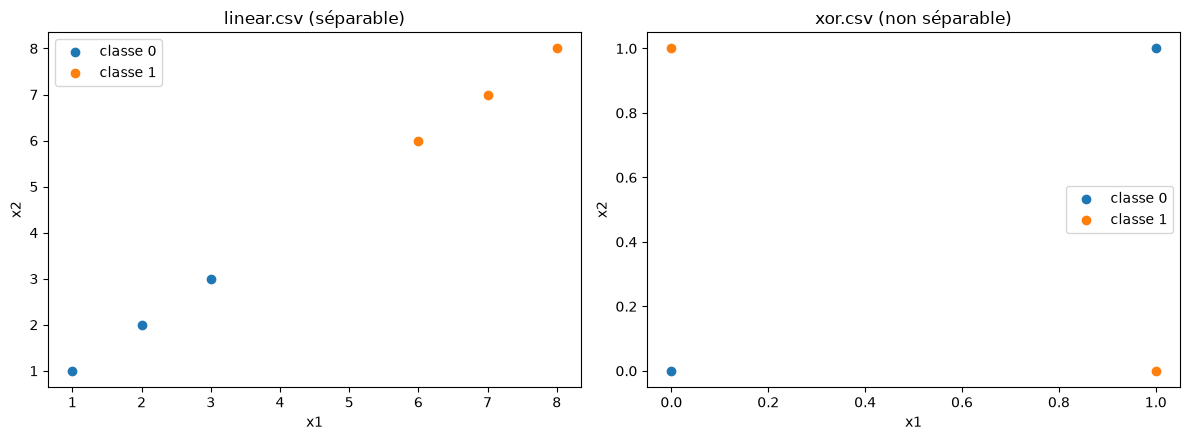

In [14]:
fig, (gauche, droite) = plt.subplots(1, 2, figsize=(12, 4.5))

# --- Nuage de gauche : linear ---
for classe in [0, 1]:
    points = linear[linear["label"] == classe]
    gauche.scatter(points["x1"], points["x2"], label="classe " + str(classe))
gauche.set_title("linear.csv (séparable)")
gauche.set_xlabel("x1")
gauche.set_ylabel("x2")
gauche.legend()

# --- Nuage de droite : xor ---
for classe in [0, 1]:
    points = xor[xor["label"] == classe]
    droite.scatter(points["x1"], points["x2"], label="classe " + str(classe))
droite.set_title("xor.csv (non séparable)")
droite.set_xlabel("x1")
droite.set_ylabel("x2")
droite.legend()

plt.tight_layout()
plt.show()

## Mise en place du perceptron

In [21]:
def entrainement_perceptron (donnees, nb_epochs = 20, lr = 0.1):
    X = donnees[["x1", "x2"]].values  
    y = donnees["label"].values 

    # poids

    w1 = 0.0
    w2 = 0.0
    b = 0.0

    accuracy_par_epoch = []

    
    for epoch in range(nb_epochs):
        for i in range(len(X)):
            x1, x2 = X[i]
            vraie_classe = y[i]

            z = w1 * x1 + w2 * x2 + b
            prediction = 1 if z > 0 else 0

            erreur = vraie_classe - prediction
            w1 = w1 + lr * erreur * x1
            w2 = w2 + lr * erreur * x2
            b = b + lr * erreur

        bonnes_reponses = 0
        for i in range(len(X)):
            z = w1 * X[i][0] + w2 * X[i][1] + b
            prediction = 1 if z > 0 else 0
            if prediction == y[i]:
                bonnes_reponses += 1
        accuracy = bonnes_reponses / len(X)
        accuracy_par_epoch.append(accuracy)

    return w1, w2, b, accuracy_par_epoch

In [ ]:
w1, w2, b, historique = entrainement_perceptron(linear)

print("Poids appris :")
print("  w1 =", round(w1, 3))
print("  w2 =", round(w2, 3))
print("  b  =", round(b, 3))
print("Accuracy à chaque epoch :")
print([round(a, 2) for a in historique])
print("Accuracy finale :", historique[-1])

Poids appris :
  w1 = 0.2
  w2 = 0.2
  b  = -1.8
Accuracy à chaque epoch :
[0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.67, 0.5, 0.67, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
Accuracy finale : 1.0


## Convergence : accuracy au fil des epochs

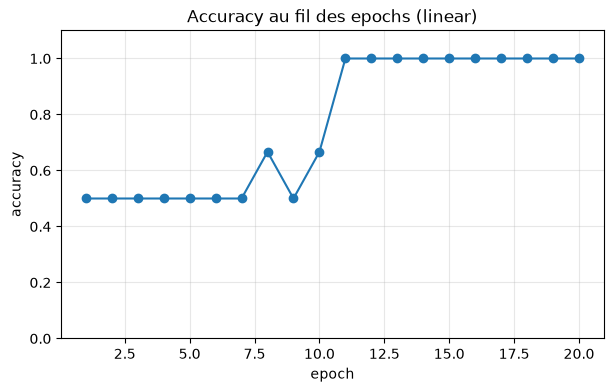

In [25]:
plt.figure(figsize=(7, 4))
plt.plot(range(1, len(historique) + 1), historique, marker="o")
plt.title("Accuracy au fil des epochs (linear)")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.ylim(0, 1.1)
plt.grid(True, alpha=0.3)
plt.show()

Entrainement sur le linear.csv

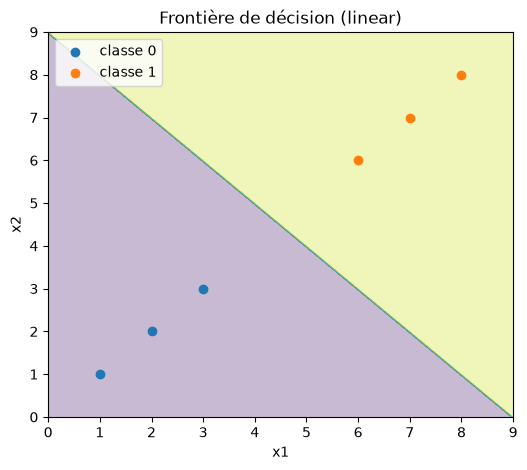

In [32]:
X = linear[["x1", "x2"]].values
y = linear["label"].values

x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
grille_x1, grille_x2 = np.meshgrid(
    np.linspace(x1_min, x1_max, 200),
    np.linspace(x2_min, x2_max, 200)
)

z = w1 * grille_x1 + w2 * grille_x2 + b
prediction_grille = np.where(z > 0, 1, 0)

plt.figure(figsize=(6, 5))
plt.contourf(grille_x1, grille_x2, prediction_grille, alpha=0.3)

for classe in [0, 1]:
    points = linear[linear["label"] == classe]
    plt.scatter(points["x1"], points["x2"], label="classe " + str(classe))

plt.title("Frontière de décision (linear)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.show()

Entrainement sur le XOR.csv

Accuracy finale sur xor : 0.5


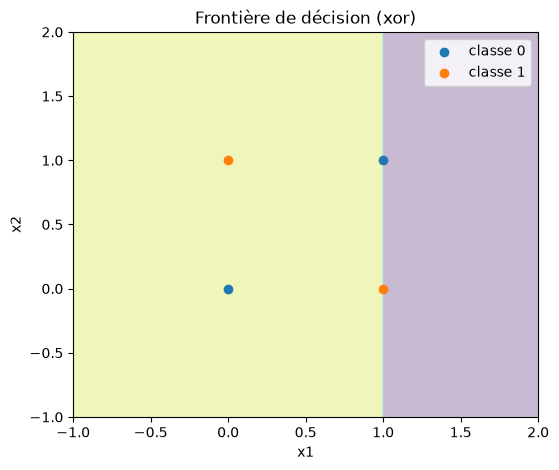

In [31]:
w1_xor, w2_xor, b_xor, historique_xor = entrainement_perceptron(xor)

print("Accuracy finale sur xor :", historique_xor[-1])

X = xor[["x1", "x2"]].values

x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
grille_x1, grille_x2 = np.meshgrid(
    np.linspace(x1_min, x1_max, 200),
    np.linspace(x2_min, x2_max, 200)
)

z = w1_xor * grille_x1 + w2_xor * grille_x2 + b_xor
prediction_grille = np.where(z > 0, 1, 0)

plt.figure(figsize=(6, 5))
plt.contourf(grille_x1, grille_x2, prediction_grille, alpha=0.3)
for classe in [0, 1]:
    points = xor[xor["label"] == classe]
    plt.scatter(points["x1"], points["x2"], label="classe " + str(classe))
plt.title("Frontière de décision (xor)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.show()